In [1]:
import torch
from vggt.models.vggt import VGGT # need to have the vggt folder (not the repo) inside of the repo
from vggt.utils.load_fn import load_and_preprocess_images

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
# bfloat16 is supported on Ampere GPUs (Compute Capability 8.0+) 
dtype = torch.bfloat16 if torch.cuda.get_device_capability()[0] >= 8 else torch.float16

cuda


In [3]:
model = VGGT.from_pretrained("facebook/VGGT-1B").to(device)

config.json:   0%|          | 0.00/62.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/5.03G [00:00<?, ?B/s]

In [4]:
model

VGGT(
  (aggregator): Aggregator(
    (patch_embed): DinoVisionTransformer(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14))
        (norm): Identity()
      )
      (blocks): ModuleList(
        (0-23): 24 x NestedTensorBlock(
          (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (attn): MemEffAttention(
            (qkv): Linear(in_features=1024, out_features=3072, bias=True)
            (q_norm): Identity()
            (k_norm): Identity()
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=1024, out_features=1024, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
          )
          (ls1): LayerScale()
          (drop_path1): Identity()
          (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=1024, out_features=4096, bias=True)
            (act): GELU(approximate=

In [67]:
# Load and preprocess example images (replace with your own image paths)
image_names = ["BlendedMVS/5a3ca9cb270f0e3f14d0eddb/blended_images/00000000_masked.jpg", "BlendedMVS/5a3ca9cb270f0e3f14d0eddb/blended_images/00000010_masked.jpg", "BlendedMVS/5a3ca9cb270f0e3f14d0eddb/blended_images/00000020_masked.jpg"]  
#image_names = ["image1.jpg", "image2.jpg", "image3.jpg"]
images = load_and_preprocess_images(image_names).to(device)

with torch.no_grad():
    with torch.cuda.amp.autocast(dtype=dtype):
        # Predict attributes including cameras, depth maps, and point maps.
        predictions = model(images)
#predictions

In [68]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def visualize_multiview_depth(images, predictions):
    depth = predictions["depth"].squeeze(0)[..., 0].cpu().numpy()  # (3, H, W)
    depth_fused = np.median(depth, axis=0)  # (H, W)
    vmin, vmax = depth.min(), depth.max()

    fig = plt.figure(figsize=(16, 8), facecolor='#0e0e0e')
    gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.15, wspace=0.05)

    for i in range(3):
        ax = fig.add_subplot(gs[0, i])
        img = images[i]
        if isinstance(img, torch.Tensor):
            img = img.cpu().numpy()
        if img.shape[0] == 3:
            img = img.transpose(1, 2, 0)
        ax.imshow(img)
        ax.set_title(f'View {i+1}', color='#aaa', fontsize=10, pad=4)
        ax.axis('off')

    ax = fig.add_subplot(gs[0, 3])
    im_fused = ax.imshow(depth_fused, cmap='magma', vmin=vmin, vmax=vmax)
    ax.set_title('Fused depth (median)', color='#aaa', fontsize=10, pad=4)
    ax.axis('off')
    fig.colorbar(im_fused, ax=ax, fraction=0.046, pad=0.04).ax.yaxis.set_tick_params(color='#aaa')

    for i in range(3):
        ax = fig.add_subplot(gs[1, i])
        ax.imshow(depth[i], cmap='magma', vmin=vmin, vmax=vmax)
        ax.set_title(f'Depth view {i+1}', color='#aaa', fontsize=10, pad=4)
        ax.axis('off')

    ax = fig.add_subplot(gs[1, 3])
    depth_std = np.std(depth, axis=0)
    im_std = ax.imshow(depth_std, cmap='hot')
    ax.set_title('Cross-view std', color='#aaa', fontsize=10, pad=4)
    ax.axis('off')
    cb = fig.colorbar(im_std, ax=ax, fraction=0.046, pad=0.04)
    cb.ax.yaxis.set_tick_params(color='#aaa')
    plt.setp(cb.ax.yaxis.get_ticklabels(), color='#aaa')

    plt.savefig('depth_visualization.png', dpi=150, bbox_inches='tight', facecolor='#0e0e0e')
    plt.show()


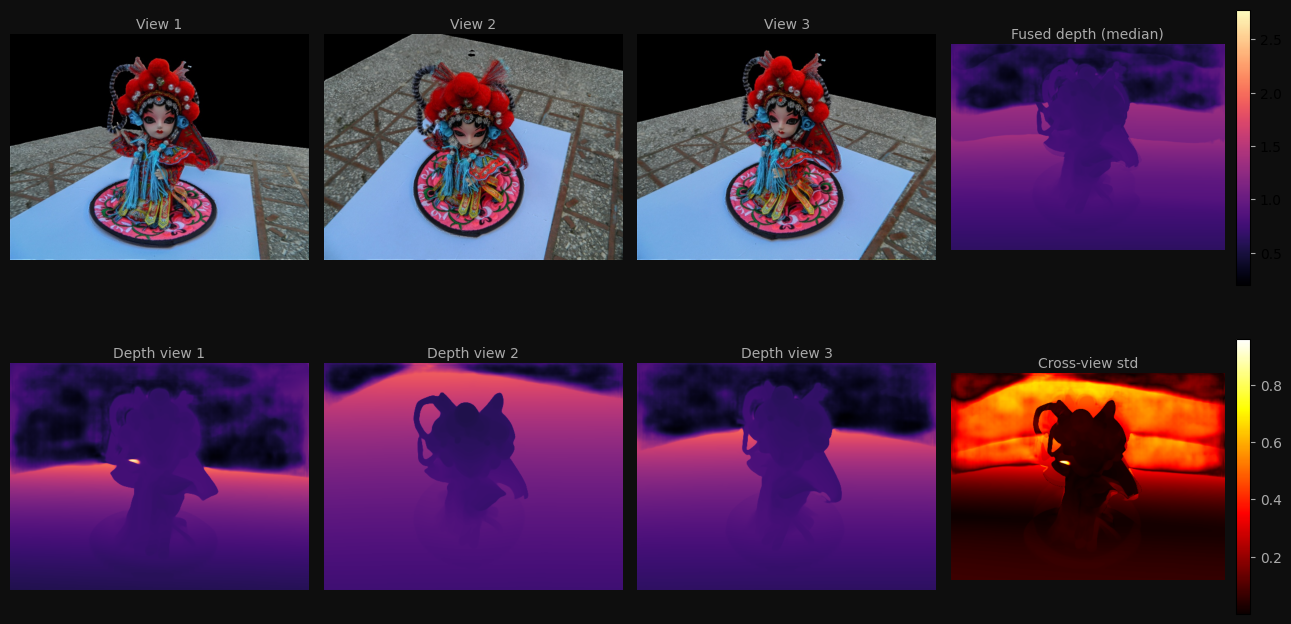

In [69]:
visualize_multiview_depth(images, predictions)

In [ ]:
import plotly.io as pio
pio.renderers.default = 'iframe'

In [47]:
import matplotlib.pyplot as plt
import numpy as np

pts  = predictions["world_points"].squeeze(0).reshape(-1, 3).cpu().numpy()
conf = predictions["world_points_conf"].squeeze(0).reshape(-1).cpu().numpy()

# filter by confidence
mask = conf > 0.5
pts_filtered = pts[mask]

# get colors from view 0
img0 = images[0]
if isinstance(img0, torch.Tensor):
    img0 = img0.cpu().numpy()
if img0.shape[0] == 3:
    img0 = img0.transpose(1, 2, 0)

# each view contributes H*W points, take view 0's colors
H, W = img0.shape[:2]
all_colors = np.concatenate([images[i].cpu().numpy().transpose(1,2,0).reshape(-1,3) 
                              for i in range(3)], axis=0)
colors_filtered = all_colors[mask]

import plotly.graph_objects as go

fig = go.Figure(data=[go.Scatter3d(
    x=pts_filtered[idx, 0],
    y=pts_filtered[idx, 1],
    z=pts_filtered[idx, 2],
    mode='markers',
    marker=dict(
        size=1.5,
        color=[f'rgb({int(r*255)},{int(g*255)},{int(b*255)})' 
               for r,g,b in np.clip(colors_filtered[idx], 0, 1)],
    )
)])
fig.update_layout(scene=dict(xaxis_visible=False, yaxis_visible=False, zaxis_visible=False))
fig.show()

In [56]:
import numpy as np
import matplotlib.pyplot as plt
import re

def read_pfm(filepath):
    with open(filepath, 'rb') as f:
        # read header line by line
        header = f.readline().decode('latin-1').strip()
        assert header in ('PF', 'Pf'), f"Not a PFM file: {header}"
        
        dims = f.readline().decode('latin-1').strip()
        W, H = map(int, dims.split())
        
        scale = float(f.readline().decode('latin-1').strip())
        endian = '<' if scale < 0 else '>'
        
        # read the rest as raw bytes — no skipping
        data = np.frombuffer(f.read(), dtype=np.dtype(endian + 'f'))
    
    data = data.reshape((H, W))[::-1].copy()  # flip vertical
    return data

In [70]:
def show_depth_error(pred_depth, gt_path, view_idx=0):
    """
    pred_depth: (3, H, W) numpy array from VGGT
    gt_path: path to .pfm file for this view
    """
    gt = read_pfm(gt_path)                    # (H, W)
    pred = pred_depth[view_idx]               # (H, W)

    # resize pred to match gt if needed
    if pred.shape != gt.shape:
        from skimage.transform import resize
        pred = resize(pred, gt.shape, anti_aliasing=True)

    # valid mask — ignore zero/invalid gt pixels
    mask = gt > 0

    # scale alignment (VGGT is affine-invariant)
    scale = np.median(gt[mask]) / np.median(pred[mask])
    pred_aligned = pred * scale

    # metrics
    abs_rel = np.mean(np.abs(pred_aligned[mask] - gt[mask]) / gt[mask])
    rmse    = np.sqrt(np.mean((pred_aligned[mask] - gt[mask]) ** 2))
    print(f"AbsRel: {abs_rel:.4f}  |  RMSE: {rmse:.4f}")

    # error map
    error = np.abs(pred_aligned - gt)
    error[~mask] = np.nan

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), facecolor='#0e0e0e')
    titles = ['GT depth', 'Predicted depth (aligned)', 'Absolute error']
    maps   = [gt, pred_aligned, error]
    cmaps  = ['magma', 'magma', 'hot']

    for ax, data, title, cmap in zip(axes, maps, titles, cmaps):
        im = ax.imshow(data, cmap=cmap)
        ax.set_title(title, color='#aaa', fontsize=10)
        ax.axis('off')
        cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cb.ax.yaxis.set_tick_params(color='#aaa')
        plt.setp(cb.ax.yaxis.get_ticklabels(), color='#aaa')

    plt.suptitle(f'AbsRel: {abs_rel:.4f}  |  RMSE: {rmse:.4f}',
                 color='white', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig(f'depth_error_view{view_idx}.png', dpi=150,
                bbox_inches='tight', facecolor='#0e0e0e')
    plt.show()
    
    return {"AbsRel": abs_rel, "RMSE": rmse}

AbsRel: 0.0222  |  RMSE: 0.1048


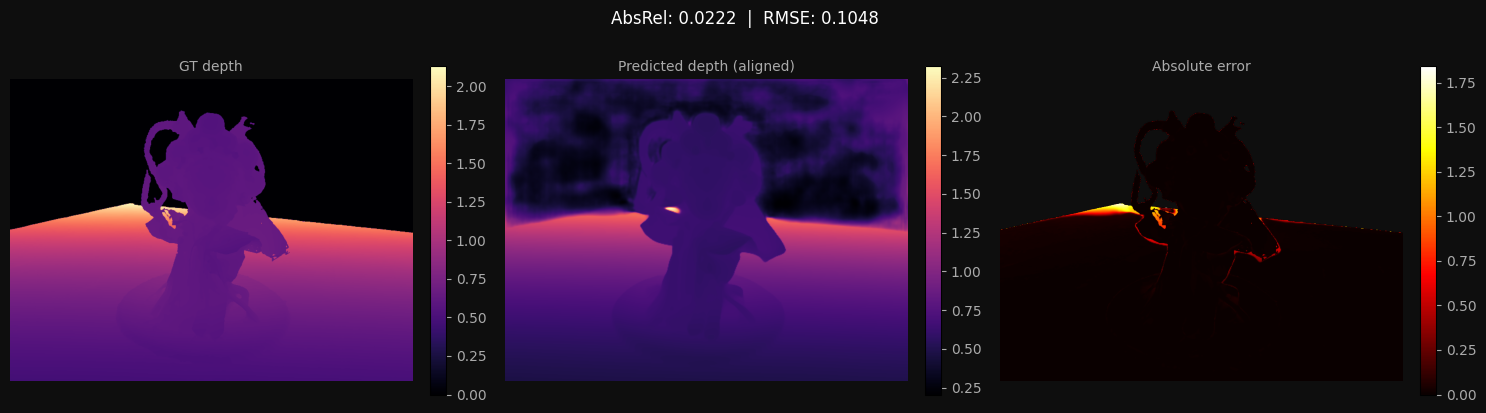

In [71]:
depth = predictions["depth"].squeeze(0)[..., 0].cpu().numpy()  # (3, H, W)
metrics = show_depth_error(depth, gt_path="BlendedMVS/5a3ca9cb270f0e3f14d0eddb/rendered_depth_maps/00000000.pfm", view_idx=0)